<a href="https://www.kaggle.com/code/wajiha1khan/image-classification-using-cnn?scriptVersionId=314593522" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/saurabhkudesia/emnist-letter-dataset/emnist-letters-test-labels-idx1-ubyte
/kaggle/input/datasets/saurabhkudesia/emnist-letter-dataset/emnist-letters-train-labels-idx1-ubyte
/kaggle/input/datasets/saurabhkudesia/emnist-letter-dataset/emnist-letters-test-images-idx3-ubyte
/kaggle/input/datasets/saurabhkudesia/emnist-letter-dataset/emnist-letters-train-images-idx3-ubyte
/kaggle/input/datasets/karimabdulnabi/fruit-classification10-class/MY_data/predict/0124.jpeg
/kaggle/input/datasets/karimabdulnabi/fruit-classification10-class/MY_data/predict/023.jpeg
/kaggle/input/datasets/karimabdulnabi/fruit-classification10-class/MY_data/predict/365.jpeg
/kaggle/input/datasets/karimabdulnabi/fruit-classification10-class/MY_data/predict/659.jpeg
/kaggle/input/datasets/karimabdulnabi/fruit-classification10-class/MY_data/predict/img_241.jpeg
/kaggle/input/datasets/karimabdulnabi/fruit-classification10-class/MY_data/predict/22.jpeg
/kaggle/input/datasets/karimabdulnabi/fruit-classi

# **TASK NO:1**


2026-04-26 14:32:23.170599: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777213943.429094      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777213943.500460      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777213944.141558      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777213944.141601      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777213944.141604      16 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-26 14:32:53.005330: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.9123 - loss: 0.2903
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9860 - loss: 0.0441
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9909 - loss: 0.0275
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9937 - loss: 0.0195
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9956 - loss: 0.0131
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9887 - loss: 0.0369
Test Accuracy: 0.9908000230789185
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


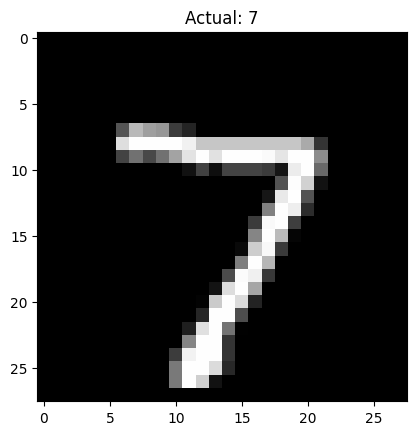

Predicted: 7


In [2]:
 import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)

loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

prediction = model.predict(x_test)

plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Actual: " + str(y_test[0]))
plt.show()

print("Predicted:", np.argmax(prediction[0]))

# **TASK NO:2**

Classes: ['Apple', 'Banana', 'avocado', 'cherry', 'kiwi', 'mango', 'orange', 'pinenapple', 'strawberries', 'watermelon']

--- Loading Data ---
Found 1841 images belonging to 10 classes.
Found 460 images belonging to 10 classes.
Found 1025 images belonging to 10 classes.

--- Starting Training ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 264ms/step - accuracy: 0.1618 - loss: 2.2486 - val_accuracy: 0.3065 - val_loss: 1.7343
Epoch 2/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 15s 171ms/step - accuracy: 0.3175 - loss: 1.8046 - val_accuracy: 0.3891 - val_loss: 1.5484
Epoch 3/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - accuracy: 0.3753 - loss: 1.5890 - val_accuracy: 0.4109 - val_loss: 1.5607
Epoch 4/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.4391 - loss: 1.4862 - val_accuracy: 0.4739 - val_loss: 1.3549
Epoch 5/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 175ms/step - accuracy: 0.4804 - loss: 1.3875 - val_accuracy: 0.4761 - val_loss: 1.4033

Test Accuracy : 37.07%
Test Loss     : 1.7526

--- Making Predictions ---


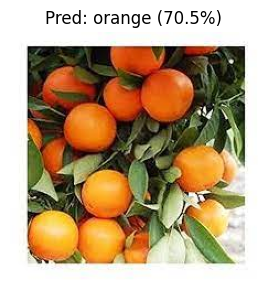

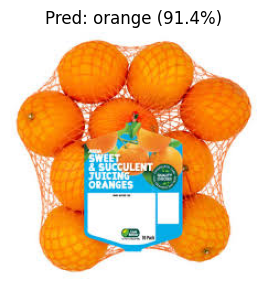

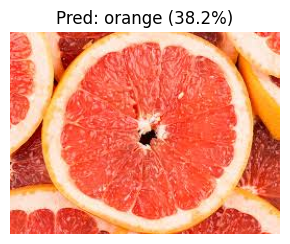

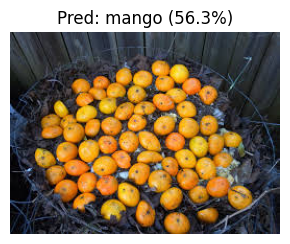

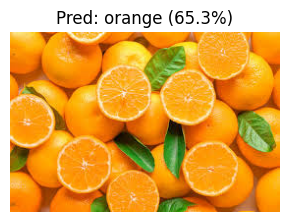

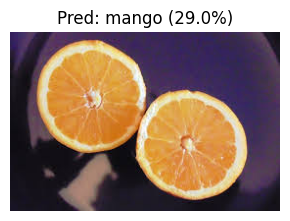

In [3]:
 import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

IMG_SIZE   = (64, 64)
BATCH_SIZE = 32
EPOCHS     = 5

BASE      = "/kaggle/input/datasets/karimabdulnabi/fruit-classification10-class/MY_data"
TRAIN_DIR = os.path.join(BASE, "train")
TEST_DIR  = os.path.join(BASE, "test")

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
print("Classes:", CLASS_NAMES)

train_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2,
                                zoom_range=0.2, horizontal_flip=True)

print("\n--- Loading Data ---")
train_data = train_gen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE,
                batch_size=BATCH_SIZE, class_mode='categorical', subset='training')

val_data   = train_gen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE,
                batch_size=BATCH_SIZE, class_mode='categorical', subset='validation')

test_data  = ImageDataGenerator(rescale=1./255).flow_from_directory(
                TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                class_mode='categorical', shuffle=False)

model = Sequential([
    Conv2D(32,  (3,3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64,  (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(len(CLASS_NAMES), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n--- Starting Training ---")
history = model.fit(train_data, epochs=EPOCHS, validation_data=val_data)

loss, acc = model.evaluate(test_data, verbose=0)
print(f"\nTest Accuracy : {acc*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

print("\n--- Making Predictions ---")
test_images = glob.glob(TEST_DIR + "/*/*")[:6]

for img_path in test_images:
    img      = image.load_img(img_path, target_size=IMG_SIZE)
    x        = image.img_to_array(img) / 255.0
    x        = np.expand_dims(x, axis=0)
    probs    = model.predict(x, verbose=0)[0]
    idx      = np.argmax(probs)
    label    = f"Pred: {CLASS_NAMES[idx]} ({probs[idx]*100:.1f}%)"

    plt.figure(figsize=(3, 3))
    plt.imshow(image.load_img(img_path))
    plt.title(label, fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()